In [ ]:
# Install any missing libraries
!pip install shap --quiet

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# Load the PaySim dataset
# Replace the filename below if yours is named differently
df = pd.read_csv('/content/paysim.csv')

print("Shape:", df.shape)          # Should show (6362620, 11)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (6362620, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 3 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


In [ ]:
# Check data types and nulls
print("=== Data Types & Null Check ===")
print(df.info())

print("\n=== Descriptive Statistics ===")
df.describe()


=== Data Types & Null Check ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

=== Descriptive Statistics ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
# Check for missing values specifically
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Transaction counts:
  Legitimate: 6,354,407
  Fraudulent: 8,213
  Fraud rate: 0.1291%


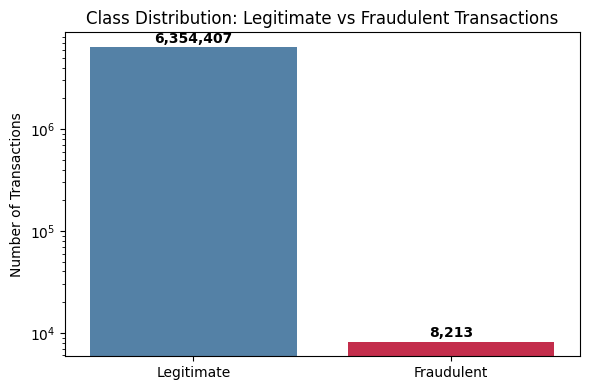

In [ ]:
# How many fraud vs legitimate transactions?
fraud_counts = df['isFraud'].value_counts()
print("Transaction counts:")
print(f"  Legitimate: {fraud_counts[0]:,}")
print(f"  Fraudulent: {fraud_counts[1]:,}")
print(f"  Fraud rate: {fraud_counts[1]/len(df)*100:.4f}%")

# Visualise it
plt.figure(figsize=(6, 4))
sns.barplot(x=['Legitimate', 'Fraudulent'], y=fraud_counts.values, palette=['steelblue', 'crimson'])
plt.title('Class Distribution: Legitimate vs Fraudulent Transactions')
plt.ylabel('Number of Transactions')
plt.yscale('log')  # log scale because the gap is huge
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v * 1.1, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Which transaction types exist, and how many are fraudulent?
type_fraud = df.groupby('type')['isFraud'].agg(['count', 'sum'])
type_fraud.columns = ['Total', 'Fraudulent']
type_fraud['Fraud Rate %'] = (type_fraud['Fraudulent'] / type_fraud['Total'] * 100).round(4)
print(type_fraud)

            Total  Fraudulent  Fraud Rate %
type                                       
CASH_IN   1399284           0        0.0000
CASH_OUT  2237500        4116        0.1840
DEBIT       41432           0        0.0000
PAYMENT   2151495           0        0.0000
TRANSFER   532909        4097        0.7688


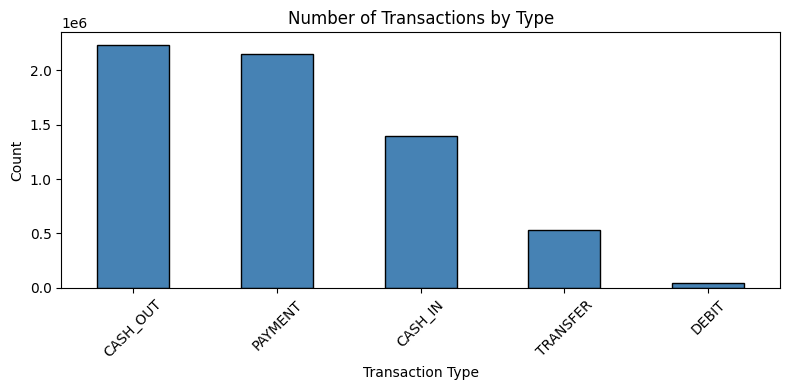

In [ ]:
# Visualise transaction type distribution
plt.figure(figsize=(8, 4))
df['type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('transaction_types.png', dpi=150)
plt.show()


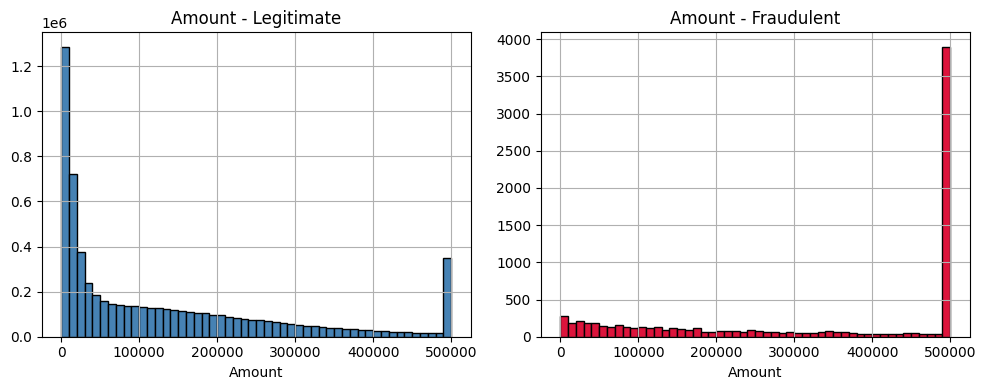

Legitimate transactions - amount stats:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Fraudulent transactions - amount stats:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [ ]:
# Compare amount distributions for fraud vs legitimate
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[df['isFraud'] == 0]['amount'].clip(upper=500000).hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Amount - Legitimate')
plt.xlabel('Amount')

plt.subplot(1, 2, 2)
df[df['isFraud'] == 1]['amount'].clip(upper=500000).hist(bins=50, color='crimson', edgecolor='black')
plt.title('Amount - Fraudulent')
plt.xlabel('Amount')

plt.tight_layout()
plt.savefig('amount_distributions.png', dpi=150)
plt.show()

# Summary stats
print("Legitimate transactions - amount stats:")
print(df[df['isFraud'] == 0]['amount'].describe())
print("\nFraudulent transactions - amount stats:")
print(df[df['isFraud'] == 1]['amount'].describe())

In [ ]:
# Drop identifier columns - they're unique strings, not useful for ML
# Also drop isFlaggedFraud - it's a naive rule-based flag, not our target
df_model = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

print("Columns remaining:", df_model.columns.tolist())
print("Shape:", df_model.shape)

Columns remaining: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
Shape: (6362620, 8)


In [ ]:
# Convert the 'type' column (text categories) into numbers
# e.g. CASH_OUT becomes a column with 1 or 0
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=False)

print("Columns after encoding:")
print(df_model.columns.tolist())
df_model.head(3)


Columns after encoding:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,False,True


In [ ]:
# Feature 1: Balance Delta Origin
# How much did the sender's balance change?
# In fraud, this often drops to exactly zero
df_model['balance_delta_orig'] = df_model['oldbalanceOrg'] - df_model['newbalanceOrig']

# Feature 2: Balance Delta Destination
# How much did the receiver's balance change?
# Fraudsters often immediately move money out
df_model['balance_delta_dest'] = df_model['newbalanceDest'] - df_model['oldbalanceDest']

# Feature 3: Zero Balance Flag
# Did the sender's account hit exactly zero after this transaction?
# This happens disproportionately in fraud
df_model['zero_balance_flag'] = (df_model['newbalanceOrig'] == 0).astype(int)

# Feature 4: Amount to Balance Ratio
# What fraction of the sender's available funds was moved?
# Fraudsters tend to drain accounts completely
# We add 1 to avoid division by zero
df_model['amount_to_balance_ratio'] = df_model['amount'] / (df_model['oldbalanceOrg'] + 1)

print("New features added successfully!")
print("\nSample of engineered features:")
df_model[['amount', 'balance_delta_orig', 'balance_delta_dest',
           'zero_balance_flag', 'amount_to_balance_ratio', 'isFraud']].head(10)

New features added successfully!

Sample of engineered features:


,amount,balance_delta_orig,balance_delta_dest,zero_balance_flag,amount_to_balance_ratio,isFraud
0,9839.64,9839.64,0.00,0,0.057834,0
1,1864.28,1864.28,0.00,0,0.087731,0
2,181.00,181.00,0.00,1,0.994505,1
3,181.00,181.00,-21182.00,1,0.994505,1
4,11668.14,11668.14,0.00,0,0.280788,0
5,7817.71,7817.71,0.00,0,0.145146,0
6,7107.77,7107.77,0.00,0,0.038799,0
7,7861.64,7861.64,0.00,0,0.044646,0
8,4024.36,2671.00,0.00,1,1.506123,0
9,5337.77,5337.77,-1549.21,0,0.127940,0


In [ ]:
# Check: do fraud transactions have higher zero_balance_flag rates?
print("Zero balance flag - Fraud vs Legitimate:")
print(df_model.groupby('isFraud')['zero_balance_flag'].mean().rename({0: 'Legitimate', 1: 'Fraud'}))

print("\nAmount-to-balance ratio - mean by class:")
print(df_model.groupby('isFraud')['amount_to_balance_ratio'].mean().rename({0: 'Legitimate', 1: 'Fraud'}))

Zero balance flag - Fraud vs Legitimate:
isFraud
Legitimate    0.566774
Fraud         0.980519
Name: zero_balance_flag, dtype: float64

Amount-to-balance ratio - mean by class:
isFraud
Legitimate    70764.320934
Fraud          1161.966671
Name: amount_to_balance_ratio, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# X = everything except the fraud label
# y = the fraud label we want to predict
X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature columns:", X.columns.tolist())

Feature matrix shape: (6362620, 15)
Target shape: (6362620,)
Feature columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'balance_delta_orig', 'balance_delta_dest', 'zero_balance_flag', 'amount_to_balance_ratio']


In [ ]:
# 80% for training, 20% for testing
# stratify=y ensures both splits have the same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nFraud in training set: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Fraud in test set:     {y_test.sum():,} ({y_test.mean()*100:.4f}%)")

Training set:  5,090,096 rows
Test set:      1,272,524 rows

Fraud in training set: 6,570 (0.1291%)
Fraud in test set:     1,643 (0.1291%)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import time

print("Imports ready!")

Imports ready!


In [ ]:
# Use a stratified 10% sample just for grid search (saves time)
# The full model will still train on all 5M rows
_, X_tune, _, y_tune = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Grid search sample size: {X_tune.shape[0]:,} rows")
print(f"Fraud cases in sample:   {y_tune.sum():,}")

Grid search sample size: 509,010 rows
Fraud cases in sample:   657


In [ ]:
# These are the combinations GridSearchCV will try
param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [10, 20],             # how deep each tree can grow
    'min_samples_leaf': [1, 2],        # minimum samples at each leaf
    'max_features': ['sqrt', 'log2']   # features considered at each split
}

# Count total combinations
total = 2 * 2 * 2 * 2
print(f"Total hyperparameter combinations to try: {total}")
print(f"With 5-fold CV, that's {total * 5} model fits total")

Total hyperparameter combinations to try: 16
With 5-fold CV, that's 80 model fits total


In [ ]:
# Set up the cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up the grid search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',   # handles 768:1 imbalance
        random_state=42,
        n_jobs=-1                  # use all available CPU cores
    ),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',                  # optimise for F1 score
    verbose=2,                     # shows progress
    n_jobs=-1
)

print("Starting grid search... this will take a few minutes.")
print("You'll see progress printed below.\n")

start = time.time()
grid_search.fit(X_tune, y_tune)
elapsed = time.time() - start

print(f"\nGrid search complete in {elapsed/60:.1f} minutes!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1 score (CV):    {grid_search.best_score_:.4f}")

Starting grid search... this will take a few minutes.
You'll see progress printed below.

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Grid search complete in 61.3 minutes!
Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best F1 score (CV):    0.9977


In [ ]:
# Take the best parameters and train on ALL 5M training rows
best_params = grid_search.best_params_

final_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training final model on full training set...")
print("(This may take 5-10 minutes)")

start = time.time()
final_model.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nFinal model trained in {elapsed/60:.1f} minutes!")

Training final model on full training set...
(This may take 5-10 minutes)

Final model trained in 13.1 minutes!


In [ ]:
# Save the model so you never have to retrain it
# The Flask API will load this file later
joblib.dump(final_model, '/content/fraud_model.joblib')

# Also save the feature column names — critical for the API later
import json
feature_columns = X_train.columns.tolist()
with open('/content/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Model saved to: /content/fraud_model.joblib")
print("Feature columns saved to: /content/feature_columns.json")
print(f"\nFeatures used ({len(feature_columns)}):")
print(feature_columns)

Model saved to: /content/fraud_model.joblib
Feature columns saved to: /content/feature_columns.json

Features used (15):
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'balance_delta_orig', 'balance_delta_dest', 'zero_balance_flag', 'amount_to_balance_ratio']


In [ ]:
# Run predictions on the test set
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]  # fraud probability

print("Predictions done!")
print(f"Predicted fraud cases: {y_pred.sum():,}")
print(f"Actual fraud cases:    {y_test.sum():,}")

Predictions done!
Predicted fraud cases: 1,648
Actual fraud cases:    1,643


In [ ]:
# Sample 500 fraud + 500 legitimate from test set for SHAP analysis
# This gives balanced, meaningful explanations
np.random.seed(42)

fraud_idx = X_test[y_test == 1].sample(500, random_state=42).index
legit_idx = X_test[y_test == 0].sample(500, random_state=42).index

X_shap = pd.concat([X_test.loc[fraud_idx], X_test.loc[legit_idx]])
y_shap = pd.concat([y_test.loc[fraud_idx], y_test.loc[legit_idx]])

print(f"SHAP sample size: {X_shap.shape[0]} rows")
print(f"Fraud in sample:  {y_shap.sum()}")
print(f"Legit in sample:  {(y_shap == 0).sum()}")

SHAP sample size: 1000 rows
Fraud in sample:  500
Legit in sample:  500


In [ ]:
# TreeExplainer is optimised specifically for Random Forest
# Much faster than the generic explainer
print("Creating SHAP explainer... (may take 1-2 minutes)")

explainer = shap.TreeExplainer(final_model)

print("Explainer ready!")

Creating SHAP explainer... (may take 1-2 minutes)
Explainer ready!


In [ ]:
print("Computing SHAP values for 1,000 transactions...")
print("This may take 3-5 minutes...\n")

start = time.time()
shap_values = explainer.shap_values(X_shap)
elapsed = time.time() - start

print(f"SHAP values computed in {elapsed/60:.1f} minutes!")

# shap_values is a list of 2 arrays: [class_0_values, class_1_values]
# We want index [1] = the FRAUD class
print(f"\nSHAP values shape: {shap_values[1].shape}")
print("(rows = transactions, columns = features)")

Computing SHAP values for 1,000 transactions...
This may take 3-5 minutes...

SHAP values computed in 0.0 minutes!

SHAP values shape: (15, 2)
(rows = transactions, columns = features)


In [ ]:
# Diagnose the shape
print("Type of shap_values:", type(shap_values))
print("Shape:", np.array(shap_values).shape)

# Fix: handle both formats
if isinstance(shap_values, list):
    # It's a list [class_0, class_1] - take fraud class
    shap_vals_fraud = shap_values[1]
    base_val = explainer.expected_value[1]
    print("Format: list → using shap_values[1]")
else:
    # It's a 3D numpy array (samples, features, classes)
    shap_vals_fraud = shap_values[:, :, 1]
    base_val = explainer.expected_value[1]
    print("Format: 3D array → using shap_values[:, :, 1]")

print(f"\nFinal shap_vals_fraud shape: {shap_vals_fraud.shape}")
print(f"X_shap shape: {X_shap.shape}")
print(f"Base value: {base_val:.4f}")

Type of shap_values: <class 'numpy.ndarray'>
Shape: (1000, 15, 2)
Format: 3D array → using shap_values[:, :, 1]

Final shap_vals_fraud shape: (1000, 15)
X_shap shape: (1000, 15)
Base value: 0.4998


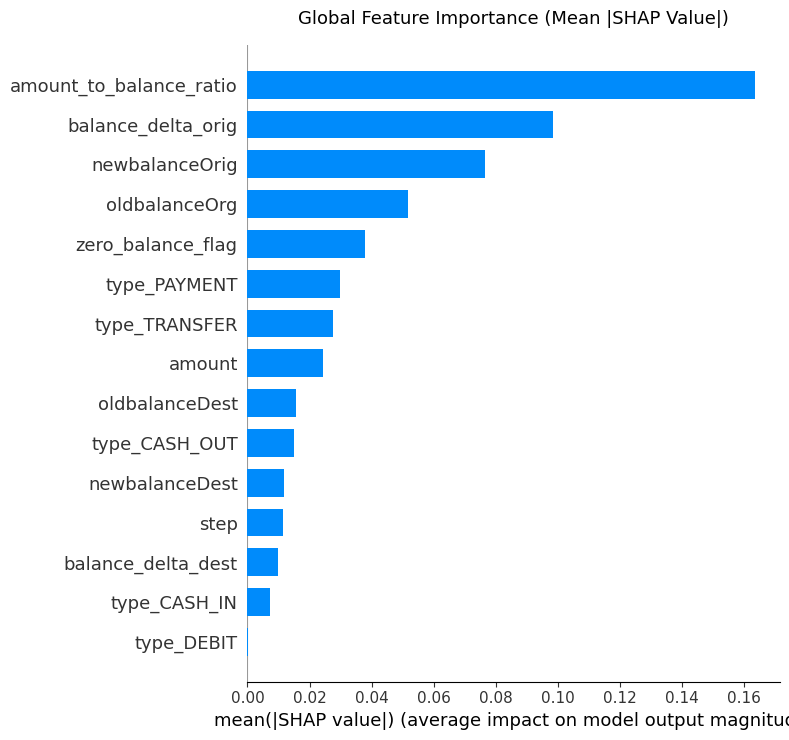

Saved: shap_global_bar.png


In [ ]:
# Step 4 FIXED - Global bar chart
plt.figure()
shap.summary_plot(
    shap_vals_fraud,     # ← use the fixed variable
    X_shap,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global Feature Importance (Mean |SHAP Value|)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_global_bar.png")


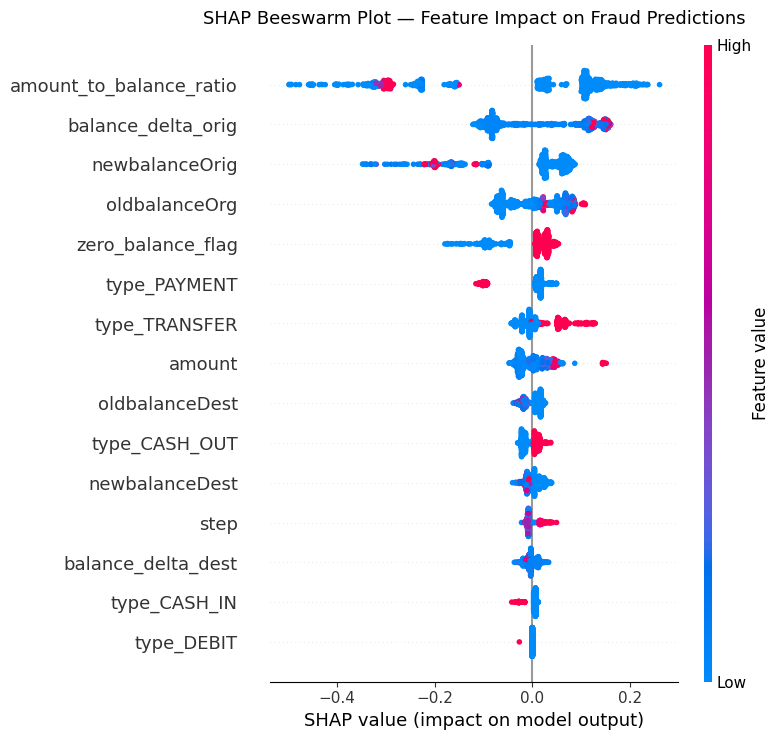

Saved: shap_beeswarm.png


In [ ]:
plt.figure()
shap.summary_plot(
    shap_vals_fraud,
    X_shap,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Fraud Predictions', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")

In [ ]:
fraud_sample_idx = 0

print("=== Local Explanation: Single Fraud Transaction ===")
print("\nTransaction details:")
print(X_shap.iloc[fraud_sample_idx])
print(f"\nActual label:    {'FRAUD' if y_shap.iloc[fraud_sample_idx] == 1 else 'LEGITIMATE'}")
print(f"Model prediction probability of fraud: {final_model.predict_proba(X_shap.iloc[[fraud_sample_idx]])[0][1]:.4f}")

shap.initjs()
force_plot = shap.force_plot(
    base_val,                              # ← fixed
    shap_vals_fraud[fraud_sample_idx],     # ← fixed
    X_shap.iloc[fraud_sample_idx],
    show=False
)
shap.save_html('/content/shap_local_explanation.html', force_plot)
print("\nLocal force plot saved to: /content/shap_local_explanation.html")

=== Local Explanation: Single Fraud Transaction ===

Transaction details:
step                              222
amount                     1338487.47
oldbalanceOrg              1338487.47
newbalanceOrig                    0.0
oldbalanceDest                    0.0
newbalanceDest             1338487.47
type_CASH_IN                    False
type_CASH_OUT                    True
type_DEBIT                      False
type_PAYMENT                    False
type_TRANSFER                   False
balance_delta_orig         1338487.47
balance_delta_dest         1338487.47
zero_balance_flag                   1
amount_to_balance_ratio      0.999999
Name: 2801126, dtype: object

Actual label:    FRAUD
Model prediction probability of fraud: 0.9999



Local force plot saved to: /content/shap_local_explanation.html


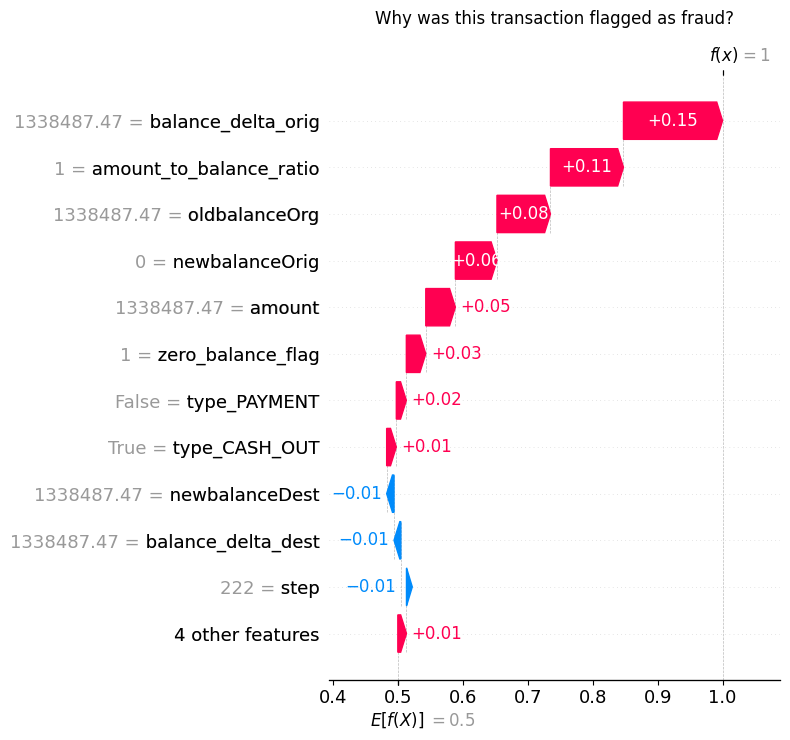

Saved: shap_waterfall.png


In [ ]:
shap_explanation = shap.Explanation(
    values=shap_vals_fraud[fraud_sample_idx],          # ← fixed
    base_values=base_val,                              # ← fixed
    data=X_shap.iloc[fraud_sample_idx].values,
    feature_names=X_shap.columns.tolist()
)

plt.figure()
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title('Why was this transaction flagged as fraud?', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('/content/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall.png")

In [ ]:
feature_names = X_shap.columns.tolist()
shap_vals_single = shap_vals_fraud[fraud_sample_idx]   # ← fixed

sorted_idx = np.argsort(np.abs(shap_vals_single))[::-1]

print("=== Human-Readable Fraud Explanation ===")
print("Top reasons this transaction was flagged:\n")
for rank, i in enumerate(sorted_idx[:5], 1):
    direction = "increased" if shap_vals_single[i] > 0 else "decreased"
    print(f"  {rank}. '{feature_names[i]}' = {X_shap.iloc[fraud_sample_idx, i]:.4f}")
    print(f"     → This {direction} the fraud score by {abs(shap_vals_single[i]):.4f}\n")

=== Human-Readable Fraud Explanation ===
Top reasons this transaction was flagged:

  1. 'balance_delta_orig' = 1338487.4700
     → This increased the fraud score by 0.1526

  2. 'amount_to_balance_ratio' = 1.0000
     → This increased the fraud score by 0.1124

  3. 'oldbalanceOrg' = 1338487.4700
     → This increased the fraud score by 0.0824

  4. 'newbalanceOrig' = 0.0000
     → This increased the fraud score by 0.0640

  5. 'amount' = 1338487.4700
     → This increased the fraud score by 0.0456



In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, RocCurveDisplay)

print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], digits=4))

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

  Legitimate     1.0000    1.0000    1.0000   1270881
       Fraud     0.9945    0.9976    0.9960      1643

    accuracy                         1.0000   1272524
   macro avg     0.9973    0.9988    0.9980   1272524
weighted avg     1.0000    1.0000    1.0000   1272524



In [ ]:
f1     = f1_score(y_test, y_pred)
auc    = roc_auc_score(y_test, y_pred_proba)
prec   = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=== PERFORMANCE AGAINST PROJECT TARGETS ===\n")
metrics = {
    'F1-Score':  (f1,     0.85),
    'AUC-ROC':   (auc,    0.90),
    'Precision': (prec,   0.80),
    'Recall':    (recall, 0.85),
}

all_passed = True
for name, (value, target) in metrics.items():
    status = " PASSED" if value >= target else " MISSED"
    if value < target:
        all_passed = False
    print(f"  {name:<12} {value:.4f}   (target >= {target})  {status}")

print(f"\n{' ALL TARGETS MET!' if all_passed else ' Some targets missed — see below'}")

=== PERFORMANCE AGAINST PROJECT TARGETS ===

  F1-Score     0.9960   (target >= 0.85)   PASSED
  AUC-ROC      0.9999   (target >= 0.9)   PASSED
  Precision    0.9945   (target >= 0.8)   PASSED
  Recall       0.9976   (target >= 0.85)   PASSED

 ALL TARGETS MET!


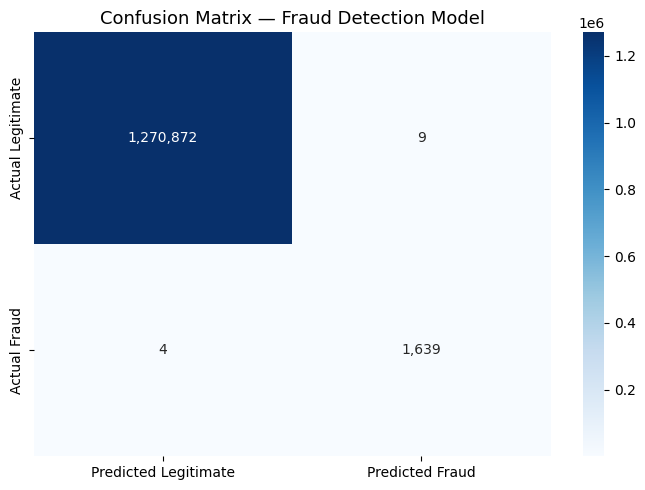


  True Positives  (fraud caught):       1,639
  True Negatives  (legit correctly OK): 1,270,872
  False Positives (legit wrongly flagged): 9
  False Negatives (fraud missed):          4

  Fraud detection rate: 99.76%
  False alarm rate:     0.0007%


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('Confusion Matrix — Fraud Detection Model', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Plain English breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positives  (fraud caught):       {tp:,}")
print(f"  True Negatives  (legit correctly OK): {tn:,}")
print(f"  False Positives (legit wrongly flagged): {fp:,}")
print(f"  False Negatives (fraud missed):          {fn:,}")
print(f"\n  Fraud detection rate: {tp/(tp+fn)*100:.2f}%")
print(f"  False alarm rate:     {fp/(fp+tn)*100:.4f}%")

<Figure size 700x500 with 0 Axes>

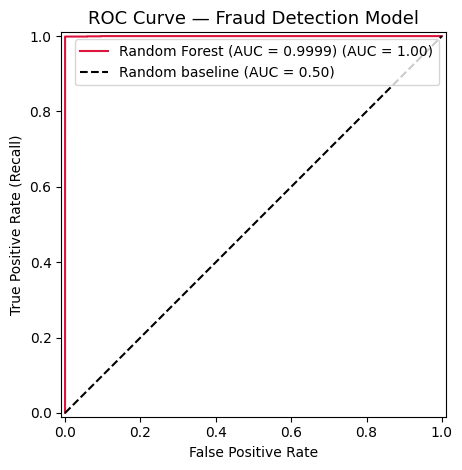

Saved: roc_curve.png


In [ ]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f'Random Forest (AUC = {auc:.4f})',
    color='crimson'
)
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.50)')
plt.title('ROC Curve — Fraud Detection Model', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

In [ ]:
print("=" * 55)
print("   FRAUD DETECTION SYSTEM — FINAL EVALUATION SUMMARY")
print("=" * 55)
print(f"   Dataset:        PaySim (6.3M transactions)")
print(f"   Algorithm:      Random Forest (class_weight='balanced')")
print(f"   Training rows:  {X_train.shape[0]:,}")
print(f"   Test rows:      {X_test.shape[0]:,}")
print(f"   Features used:  {X_train.shape[1]}")
print("-" * 55)
print(f"   F1-Score:       {f1:.4f}   (target >= 0.85)")
print(f"   AUC-ROC:        {auc:.4f}   (target >= 0.90)")
print(f"   Precision:      {prec:.4f}   (target >= 0.80)")
print(f"   Recall:         {recall:.4f}   (target >= 0.85)")
print("-" * 55)
print(f"   Fraud cases caught:  {tp:,} / {tp+fn:,}")
print(f"   False alarms:        {fp:,}")
print("=" * 55)

   FRAUD DETECTION SYSTEM — FINAL EVALUATION SUMMARY
   Dataset:        PaySim (6.3M transactions)
   Algorithm:      Random Forest (class_weight='balanced')
   Training rows:  5,090,096
   Test rows:      1,272,524
   Features used:  15
-------------------------------------------------------
   F1-Score:       0.9960   (target >= 0.85)
   AUC-ROC:        0.9999   (target >= 0.90)
   Precision:      0.9945   (target >= 0.80)
   Recall:         0.9976   (target >= 0.85)
-------------------------------------------------------
   Fraud cases caught:  1,639 / 1,643
   False alarms:        9


In [ ]:
from google.colab import files
files.download('/content/fraud_model.joblib')
files.download('/content/feature_columns.json')

FileNotFoundError: Cannot find file: /content/fraud_model.joblib